        Date   Company    Open    High     Low   Close   Volume
0 2023-01-02  TechNova  102.94  106.09  101.10  104.62  1314875
1 2023-01-03  TechNova  106.31  107.77  102.76  105.73  2948181
2 2023-01-04  TechNova  109.97  112.26  108.61  108.94  4522742
3 2023-01-05  TechNova  110.79  111.68  108.55  110.44  1473630
4 2023-01-06  TechNova  112.31  115.30  109.24  110.67  2783761

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     500 non-null    datetime64[us]
 1   Company  500 non-null    str           
 2   Open     500 non-null    float64       
 3   High     500 non-null    float64       
 4   Low      500 non-null    float64       
 5   Close    500 non-null    float64       
 6   Volume   500 non-null    int64         
dtypes: datetime64[us](1), float64(4), int64(1), str(1)
memory usage: 27.5 KB
None

                      Date       

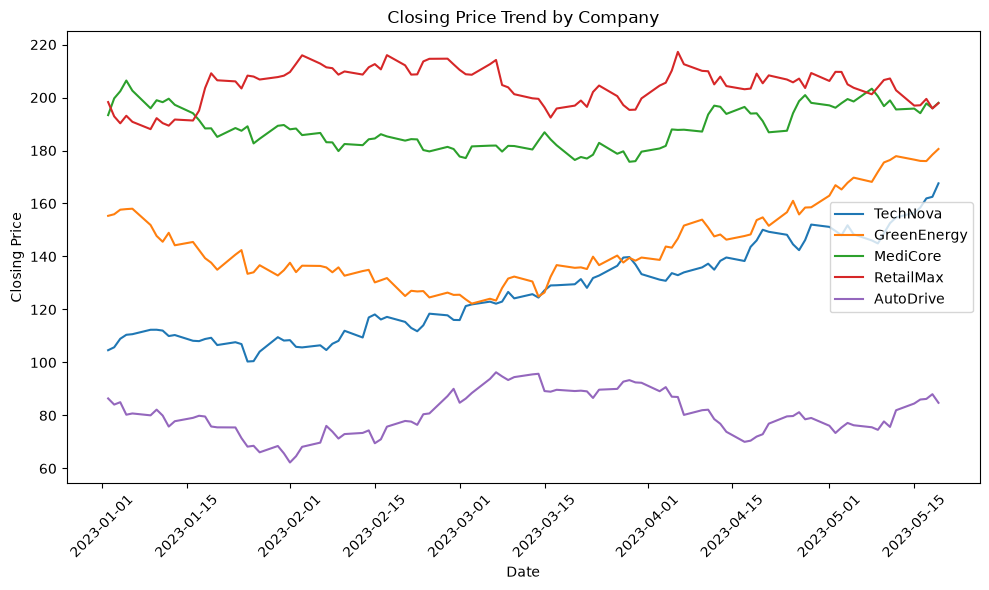

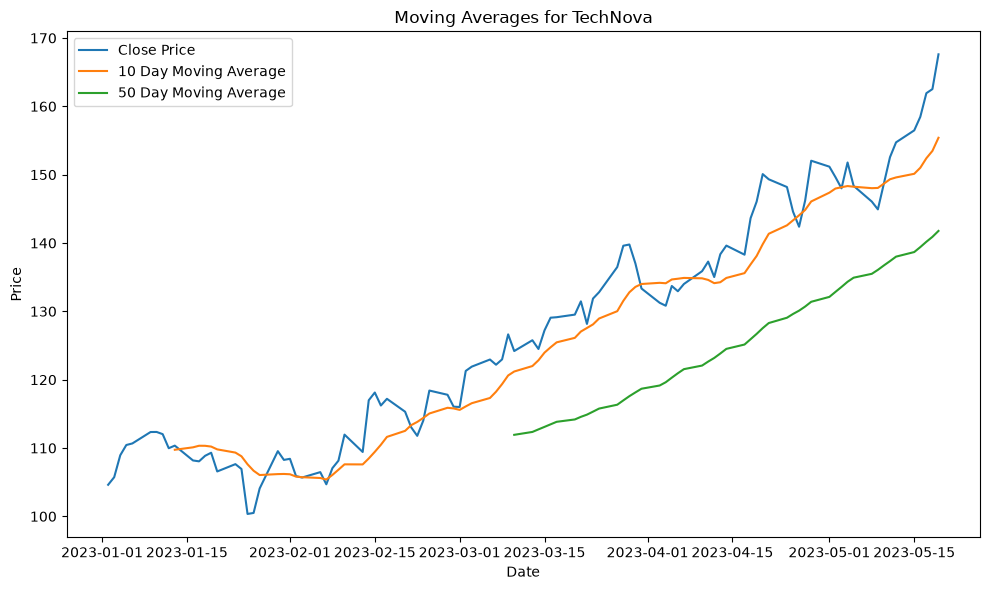

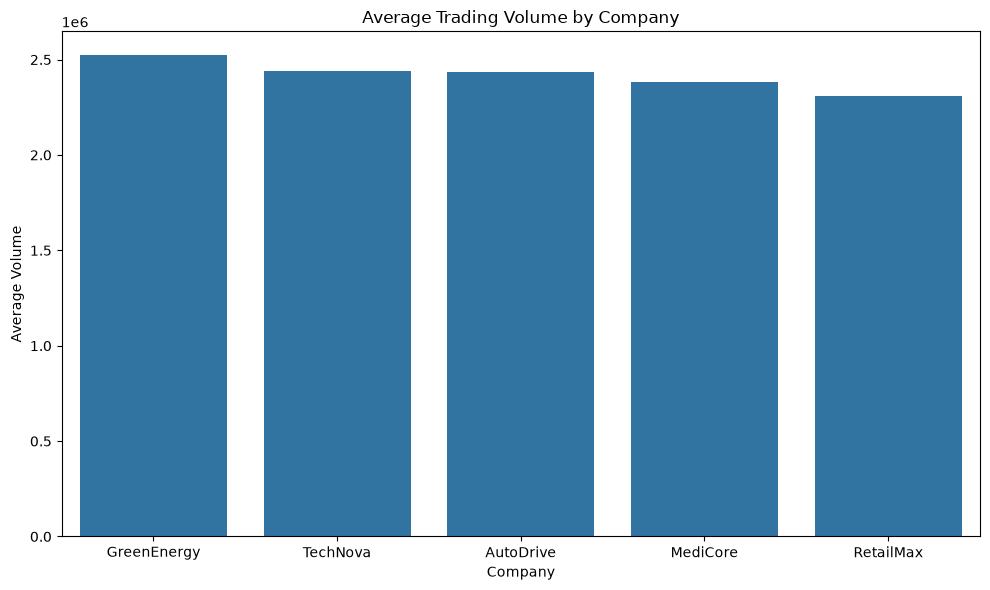

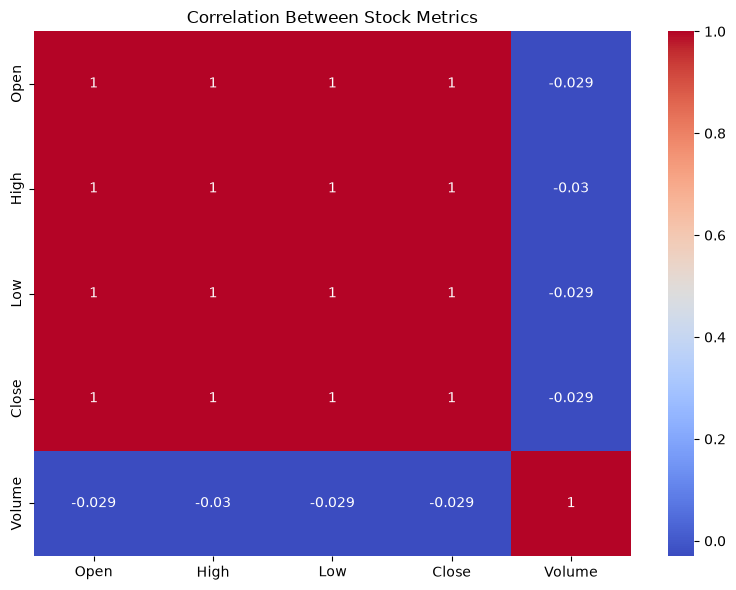

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("stock_data.csv")
df["Date"] = pd.to_datetime(df["Date"])

print(df.head())
print()
print(df.info())
print()
print(df.describe())
print()
print(df.isnull().sum())

companies = df["Company"].unique()

plt.figure(figsize=(10, 6))
for company in companies:
    company_data = df[df["Company"] == company]
    plt.plot(company_data["Date"], company_data["Close"], label=company)
plt.title("Closing Price Trend by Company")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

first_company = companies[0]
first_company_data = df[df["Company"] == first_company].copy()
first_company_data = first_company_data.sort_values("Date")
first_company_data["MA10"] = first_company_data["Close"].rolling(window=10).mean()
first_company_data["MA50"] = first_company_data["Close"].rolling(window=50).mean()

plt.figure(figsize=(10, 6))
plt.plot(first_company_data["Date"], first_company_data["Close"], label="Close Price")
plt.plot(first_company_data["Date"], first_company_data["MA10"], label="10 Day Moving Average")
plt.plot(first_company_data["Date"], first_company_data["MA50"], label="50 Day Moving Average")
plt.title("Moving Averages for " + first_company)
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()

avg_volume = df.groupby("Company")["Volume"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=avg_volume.index, y=avg_volume.values)
plt.title("Average Trading Volume by Company")
plt.xlabel("Company")
plt.ylabel("Average Volume")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
correlation = df[["Open", "High", "Low", "Close", "Volume"]].corr()
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Correlation Between Stock Metrics")
plt.tight_layout()
plt.show()

## Insight

- **Closing prices across all companies range from ~$62 to ~$217** (mean ~$149), indicating the dataset covers a mix of both lower- and higher-priced stocks over the Jan–May 2023 window.
- **Trading volume is highly variable** (mean ~2.42M shares, std ~1.44M) — some companies see multi-million share days while others trade far more thinly, which is a useful signal for liquidity risk.
- **The 10-day moving average reacts quickly to price swings while the 50-day moving average smooths out longer trends** for the first company (TechNova) — crossovers between the two lines are the classic visual cue for potential trend reversals.
- **Open, High, Low, and Close prices are almost perfectly correlated** with each other (as expected for daily OHLC data), while Volume correlates much more weakly with price — confirming that price levels and trading activity are driven by largely independent dynamics.
- **Takeaway**: companies with consistently high average volume are the more liquid, easier-to-trade names in this dataset, while price-only comparisons should be read alongside volume to judge real market interest.
